# Time Series Forecasting with TorchGeo: Air Quality Tutorial

This tutorial introduces the **time-series capabilities** added in the latest TorchGeo release. We walk through a complete forecasting workflow, from raw data to trained model to visual results, using three new components:

| Component | Description |
|-----------|-------------|
| `AirQuality` / `AirQualityDataModule` | Hourly air-quality sensor data (UCI, Italian roadside station, 2004–2005) with chronological splitting and per-feature normalisation |
| `LTAE` | Lightweight Temporal Attention Encoder — encodes a variable-length sequence `(B, T, C)` into a fixed embedding `(B, d)` |
| `TemporalRegressionTask` | Lightning module that wires the encoder to a regression head, loss function, and evaluation metrics |

**What we are predicting:** given the last `NUM_PAST_STEPS` hours across all sensor channels, forecast the next `NUM_FUTURE_STEPS` hours for all channels simultaneously.

## Setup

We import everything we need upfront. `L.seed_everything` ensures reproducible weight initialisation and data shuffling across runs.

In [1]:
import torch
import lightning as L
from torchgeo.datasets import AirQuality
from torchgeo.datamodules import AirQualityDataModule
from torchgeo.trainers import TemporalRegressionTask
import torch.nn as nn
from torchgeo.models import LTAE
from lightning import Trainer
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
L.seed_everything(0, workers=True)

/home/fschi/miniconda3/envs/torchgeo-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 0


0

## Dataset

The **UCI Air Quality dataset** contains 13 sensor channels (we remove NMHC(GT) for this analysis, which contains mostly empty readings) measured every hour for approximately 13 months at a roadside station in Italy. Missing values (encoded as `-200` in the raw data) are handled automatically by `AirQuality`.

Each sample in the dataset consists of:
- **`input`**: a window of `NUM_PAST_STEPS` hourly readings across all channels (shape `T × C`)
- **`target`**: the following `NUM_FUTURE_STEPS` hourly readings (shape `H × C`)

We set a X-hour context window and ask the model to predict X hours ahead.

In [2]:
DATA_ROOT        = 'data'
NUM_PAST_STEPS   = 5
NUM_FUTURE_STEPS = 1

dataset = AirQuality(root=DATA_ROOT, download=True,
                     num_input_steps=NUM_PAST_STEPS,
                     num_target_steps=NUM_FUTURE_STEPS)

NUM_FEATURES  = len(dataset.data.columns)
dataset.data.head()


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


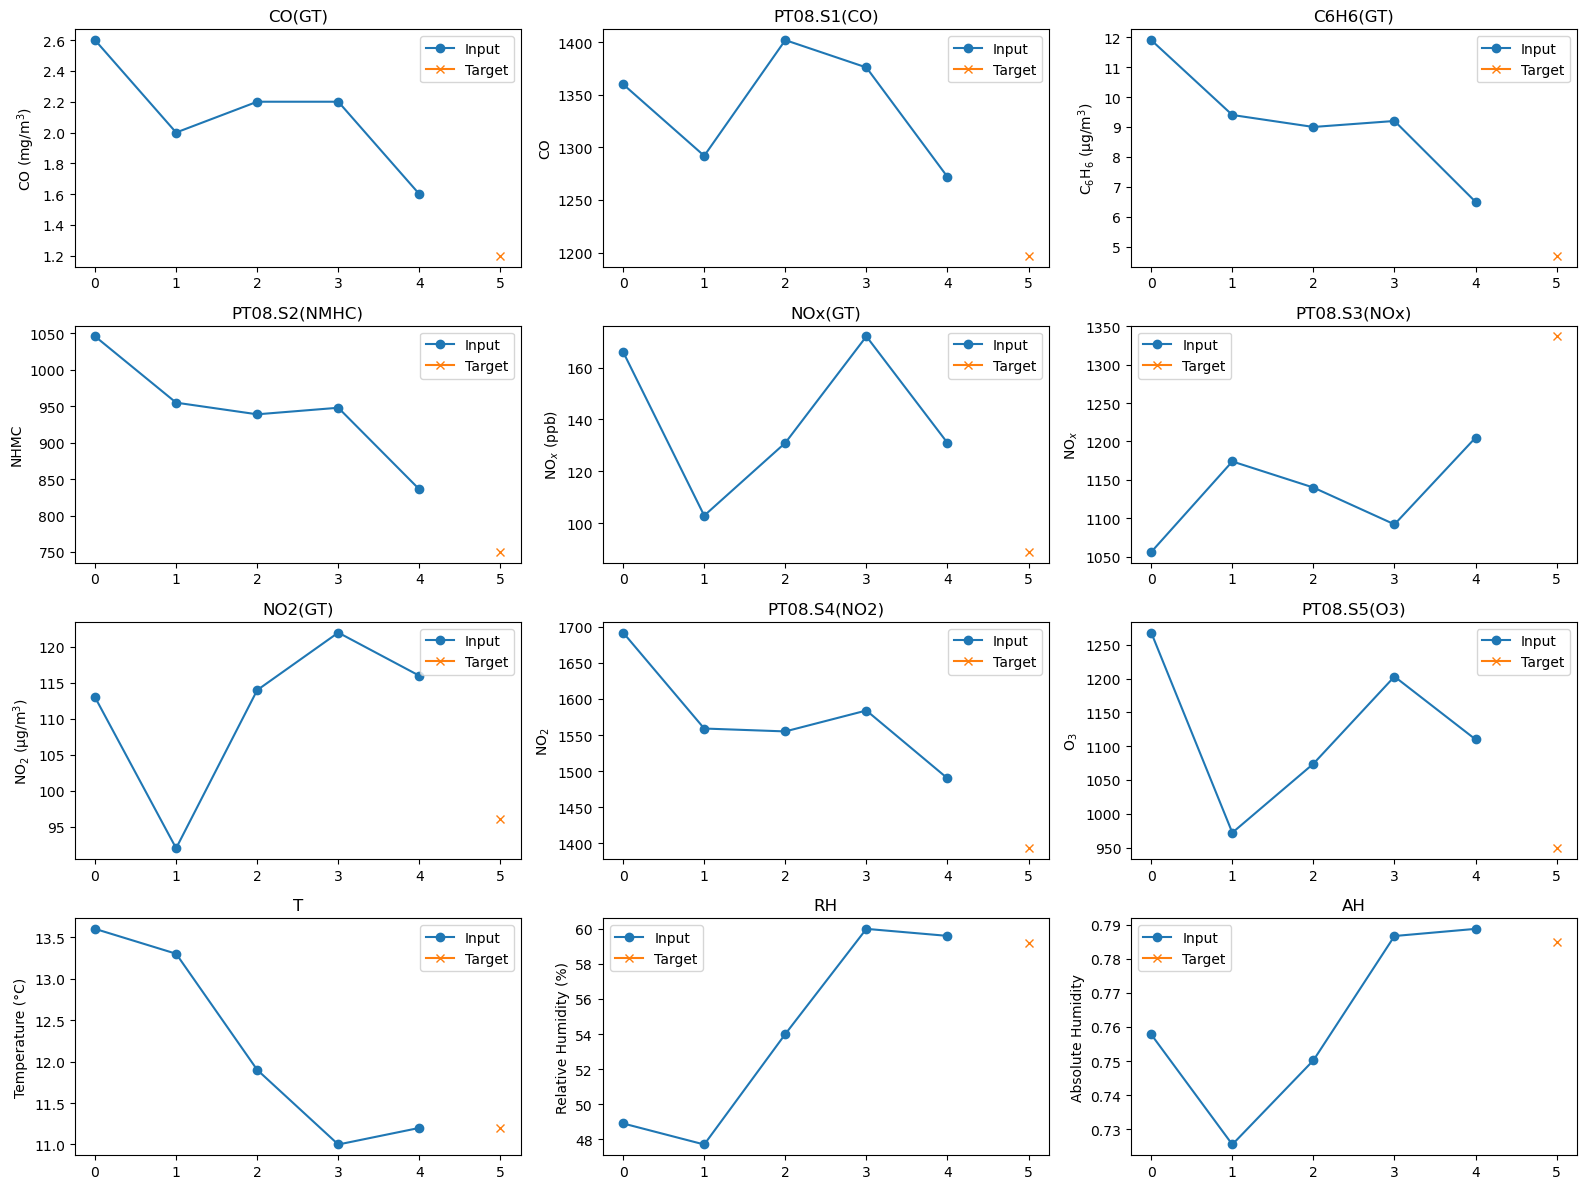

In [3]:
sample = dataset[0]
_ = dataset.plot(sample)

## Data Module and Chronological Splitting

`AirQualityDataModule` handles loading, normalisation, and splitting in one place. The split is always **chronological** — training on the earliest data, validating on the middle, and testing on the most recent, because random splits would cause temporal leakage: the model would have seen future information during training.

Per-feature z-score normalisation is computed from the training set only and applied consistently to all splits.

In [4]:
dm = AirQualityDataModule(
    root=DATA_ROOT, download=True, batch_size=128, num_workers=0,
    val_split_pct=0.15, test_split_pct=0.15,
    num_input_steps=NUM_PAST_STEPS, num_target_steps=NUM_FUTURE_STEPS,
)

## The L-TAE Model and Temporal Regression

The **Lightweight Temporal Attention Encoder** (Garnot & Landrieu, 2020) is designed for variable-length time series. Instead of processing steps sequentially like an RNN, it computes a single learned query vector that attends to *all* timesteps at once, yielding a fixed-size embedding regardless of sequence length. This architecture is well-suited for irregular or long time series: it avoids the vanishing-gradient issues of RNNs and assigns an explicit, inspectable attention weight to every timestep.

`TemporalRegressionTask` is a Lightning module that wraps the L-TAE encoder together with a linear prediction head. It handles the full training loop including:
- **Loss**: MSE computed in normalised space
- **Metrics**: RMSE and MAE reported in physical units (de-normalised before metric computation)

The output dimension `NUM_OUTPUTS = NUM_FUTURE_STEPS × NUM_FEATURES` reflects that we predict all channels at every future timestep simultaneously.

In [5]:
task = TemporalRegressionTask(
    model='ltae', in_channels=NUM_FEATURES,
    num_outputs=NUM_FUTURE_STEPS * NUM_FEATURES,
    loss='mse', lr=3e-4, patience=5,
    n_head=4, d_k=8, d_model=64, n_neurons=(64, 32),
    dropout=0.1, len_max_seq=NUM_PAST_STEPS, T=1000,
)

## Training

We use two standard Lightning callbacks:
- **`ModelCheckpoint`**: saves the weights that achieved the lowest validation loss
- **`EarlyStopping`**: halts training if validation loss does not improve for `EARLY_STOP_PATIENCE` consecutive epochs

In [6]:
trainer = Trainer(
    max_epochs=1,
    callbacks=[
        ModelCheckpoint(monitor='val_loss', mode='min', save_top_k=1),
        EarlyStopping(monitor='val_loss', patience=10, mode='min'),
    ],
)

trainer.fit(task, datamodule=dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name          | Type             | Params | Mode 
-----------------------------------------------------------
0 | model         | Sequential       | 20.7 K | train
1 | criterion     | MSELoss          | 0      | train
2 | train_metrics | MetricCollection | 0      | train
3 | val_metrics   | MetricCollection | 0      | train
4 | test_metrics  | MetricCollection | 0      | train
-----------------------------------------------------------
20.7 K    Trainable params
0         Non-trainable params
20.7 K    Total params
0.083     Total estimated model params size (MB)
30        Modules in train mode
0         Modules in eval mode


Sanity Checking:   0%|          | 0/2 [00:00<?, ?it/s]

/home/fschi/miniconda3/envs/torchgeo-dev/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=17` in the `DataLoader` to improve performance.


/home/fschi/miniconda3/envs/torchgeo-dev/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=17` in the `DataLoader` to improve performance.


Epoch 0: 100%|██████████| 51/51 [00:01<00:00, 45.21it/s, v_num=92]

`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 0: 100%|██████████| 51/51 [00:01<00:00, 44.70it/s, v_num=92]


## Evaluation

In [7]:
trainer.test(task, datamodule=dm)

/home/fschi/miniconda3/envs/torchgeo-dev/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=17` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 11/11 [00:00<00:00, 94.36it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_MAE          │    107.32456970214844     │
│         test_MSE          │       34425.3671875       │
│         test_RMSE         │    185.54074096679688     │
│         test_loss         │    0.7923165559768677     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.7923165559768677,
  'test_MAE': 107.32456970214844,
  'test_MSE': 34425.3671875,
  'test_RMSE': 185.54074096679688}]